# Level 3: Task 3 - Data Visualization

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv('../../level1/task2/cleaned_data.csv')

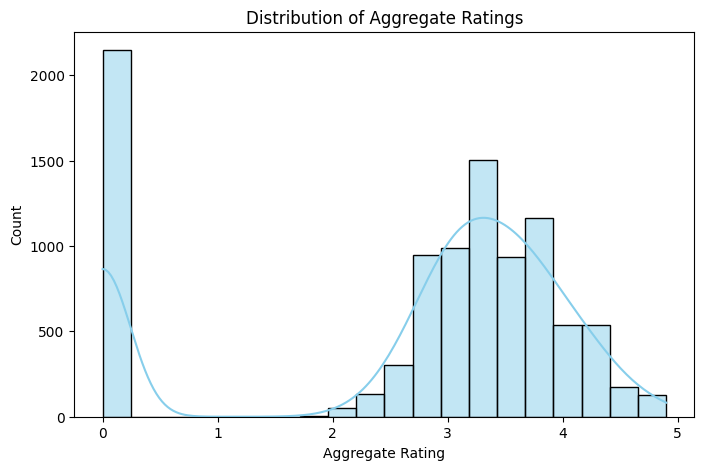

In [4]:
# Histogram of Aggregate Ratings
plt.figure(figsize=(8, 5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Count')
plt.show()

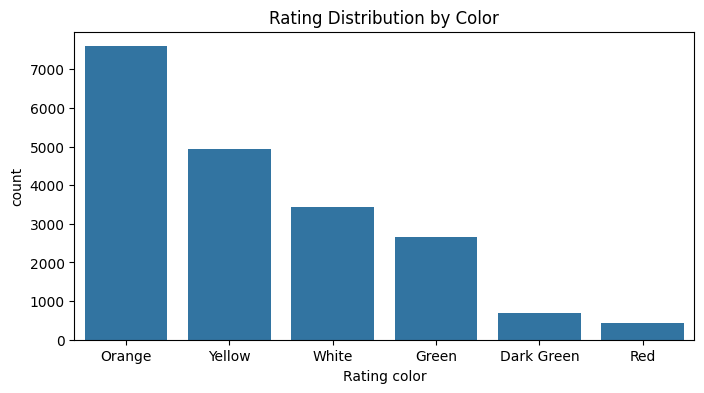

In [23]:
# Countplot by Rating Color
plt.figure(figsize=(8, 4))
sns.countplot(x='Rating color', data=df, order=df['Rating color'].value_counts().index)
plt.title('Rating Distribution by Color')
plt.show()

In [10]:
# Split and explode Cuisines
df['Cuisines'] = df['Cuisines'].apply(lambda x: [i.strip() for i in x.split(',')])
df = df.explode('Cuisines')

In [13]:
# Aggregate Rating vs Votes (Popularity)
cuisine_summary = df.groupby('Cuisines').agg({
    'Aggregate rating': 'mean',
    'Votes': 'sum'
}).reset_index()

# Sctter plot using plotly
fig = px.scatter(
    cuisine_summary,
    x='Aggregate rating',
    y='Votes',
    color='Cuisines',
    hover_name='Cuisines',
    title='Cuisine Rating vs Popularity (Votes)',
    width=800,
    height=500
)

# Remove axis labels and gridlines
fig.update_layout(
    showlegend=False,  # Hide the color legend (optional)
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()


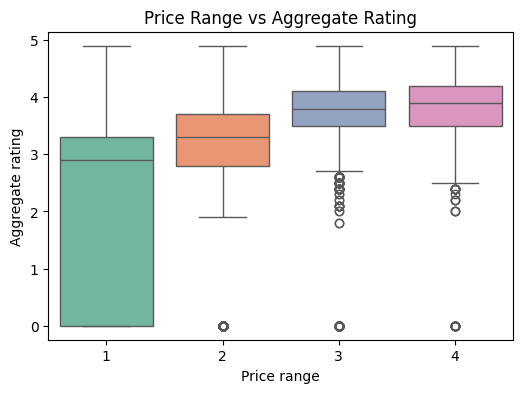

In [24]:
# Price Range vs. Rating
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Price range', y='Aggregate rating', palette='Set2')
plt.title('Price Range vs Aggregate Rating')
plt.show()

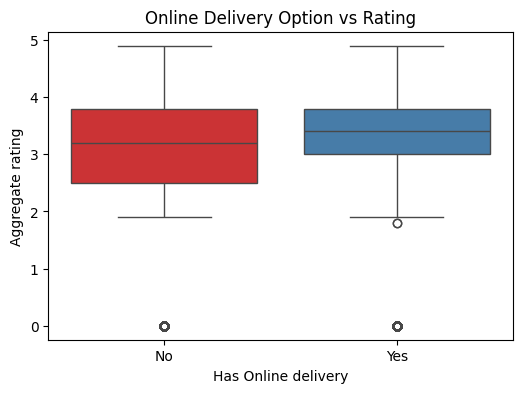

In [25]:
# Online Delivery vs. Rating
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Has Online delivery', y='Aggregate rating', palette='Set1')
plt.title('Online Delivery Option vs Rating')
plt.show()

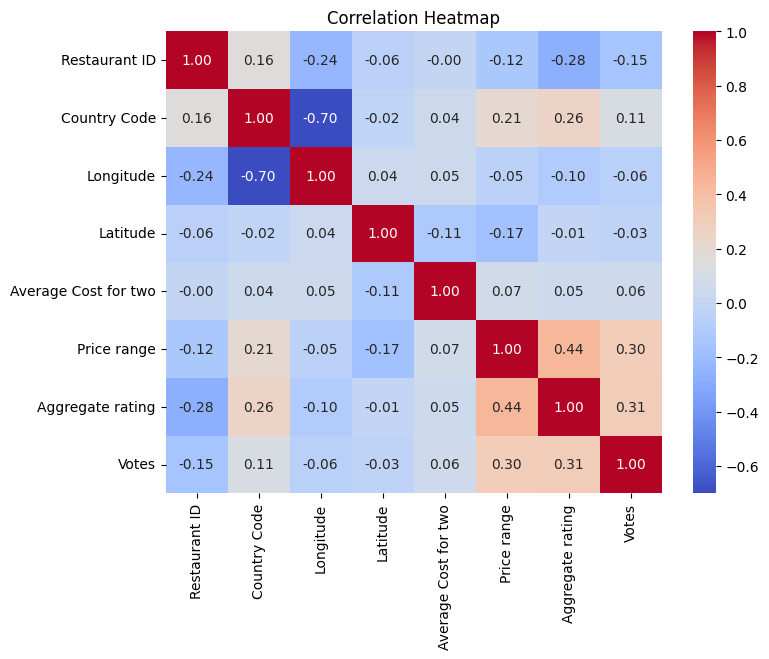

In [26]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()